# Sweep Analysis: does the AAPL 20/50 result hold up?

v1 found that a 20/50-day SMA crossover underperformed buy-and-hold on AAPL from 2019-2026. The obvious follow-up question is whether that's a real property of trend-following in this window, or just AAPL. This notebook loads `results/sweep_results.csv` (29 tickers × 19 short/long combinations, from `sweep.py`) and looks at whether the strategy actually wins anywhere.

Two caveats up front, both already noted in the README:

- **Survivorship bias:** the ticker universe is today's liquid large caps. Anything delisted, acquired, or bankrupted since 2019 isn't in it, so this is a look at "the market's winners," not a neutral cross-section.
- **Same window, same regime:** every ticker here is being tested over the exact same 2019-2026 stretch, which happened to be a strong bull run for large-cap US equities. A result that holds across tickers in this window isn't automatically a result that holds across time.

## Loading the results

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("results/sweep_results.csv")
print(f"{len(df)} cells across {df['ticker'].nunique()} tickers")
df.head()

551 cells across 29 tickers


,ticker,short,long,strategy_cagr,bh_cagr,edge,strategy_sharpe,bh_sharpe,sharpe_edge,strategy_max_drawdown,bh_max_drawdown,round_trip_trades,pct_days_in_market
0,KO,5,50,0.048965,0.097077,-0.048111,0.227510,0.435298,-0.207788,-0.172500,-0.369875,29.0,63.742690
1,KO,5,100,0.043083,0.086160,-0.043077,0.182004,0.382347,-0.200343,-0.184211,-0.369875,19.0,66.987952
2,KO,5,150,0.018412,0.081608,-0.063196,0.012540,0.360318,-0.347778,-0.196839,-0.369875,16.0,70.434783
3,KO,5,200,0.001451,0.076887,-0.075436,-0.092813,0.336002,-0.428815,-0.276150,-0.369875,15.0,73.974359
4,KO,10,50,0.051417,0.097077,-0.045659,0.243378,0.435298,-0.191920,-0.178467,-0.369875,21.5,63.391813


## The headline numbers

Two fractions matter most here: how often the strategy's CAGR beat buy-and-hold, and how often its Sharpe ratio did (since a strategy could lose on raw return but still win on risk-adjusted return, or vice versa).

In [2]:
frac_cagr_win = (df["edge"] > 0).mean()
frac_sharpe_win = (df["sharpe_edge"] > 0).mean()

print(f"Fraction of cells where strategy CAGR > buy-and-hold CAGR: {frac_cagr_win:.1%}")
print(f"Fraction of cells where strategy Sharpe > buy-and-hold Sharpe: {frac_sharpe_win:.1%}")

Fraction of cells where strategy CAGR > buy-and-hold CAGR: 7.3%
Fraction of cells where strategy Sharpe > buy-and-hold Sharpe: 9.4%


So the strategy beats buy-and-hold on CAGR in only about 1 in 14 cells, and on Sharpe in about 1 in 10. If short/long window choice were doing nothing useful, I'd expect something closer to a 50/50 split across this many combinations — not necessarily exactly 50%, since parameter choices aren't independent draws, but nowhere near this lopsided. This is a much stronger and more one-sided result than I expected going in. The AAPL 20/50 case wasn't an unlucky draw for the strategy — it's representative of what this style of crossover does against buy-and-hold almost everywhere in this universe, over this stretch.

## Where the edge distribution sits, and where AAPL 20/50 falls in it

"Edge" is strategy CAGR minus buy-and-hold CAGR, so negative means buy-and-hold won. This plots the distribution across all 551 cells and marks the original AAPL 20/50 result.

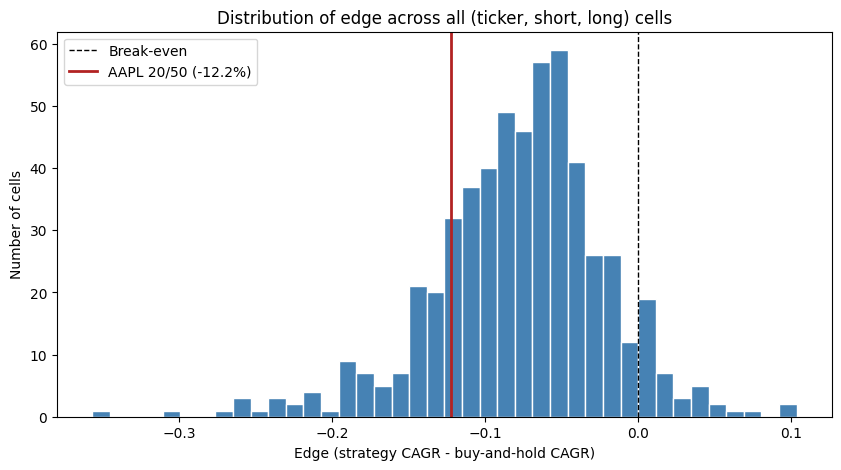

AAPL 20/50 edge: -12.24%
Percentile of AAPL 20/50 within the full distribution: 17.6%


In [3]:
aapl_20_50 = df[(df["ticker"] == "AAPL") & (df["short"] == 20) & (df["long"] == 50)]["edge"].iloc[0]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df["edge"], bins=40, color="steelblue", edgecolor="white")
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")
ax.axvline(aapl_20_50, color="firebrick", linewidth=2, label=f"AAPL 20/50 ({aapl_20_50:.1%})")
ax.set_xlabel("Edge (strategy CAGR - buy-and-hold CAGR)")
ax.set_ylabel("Number of cells")
ax.set_title("Distribution of edge across all (ticker, short, long) cells")
ax.legend()
plt.show()

print(f"AAPL 20/50 edge: {aapl_20_50:.2%}")
print(f"Percentile of AAPL 20/50 within the full distribution: {(df['edge'] < aapl_20_50).mean():.1%}")

AAPL 20/50 actually sits below the middle of this distribution — it's a somewhat *worse*-than-typical result for the strategy, not a representative or lucky one. The distribution itself is almost entirely on the losing side of zero, with a short right tail of cells that do beat buy-and-hold.

## Mean edge by (short, long) window

This averages edge across all 29 tickers for each parameter pair, to see if any part of the grid is systematically better than the rest.

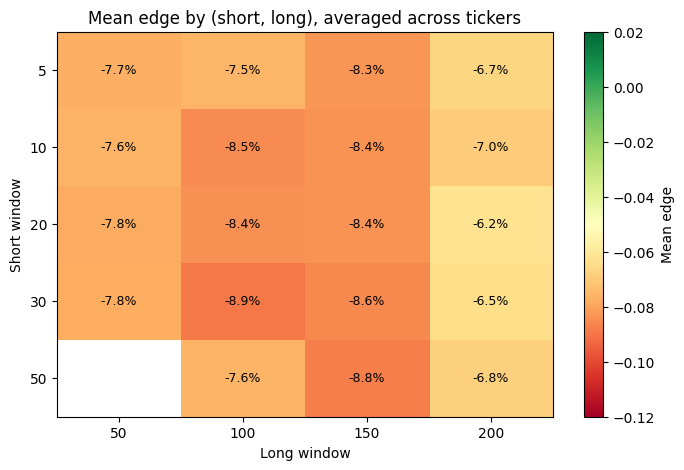

In [4]:
pivot = df.pivot_table(index="short", columns="long", values="edge", aggfunc="mean")

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(pivot.values, cmap="RdYlGn", vmin=-0.12, vmax=0.02, aspect="auto")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel("Long window")
ax.set_ylabel("Short window")
ax.set_title("Mean edge by (short, long), averaged across tickers")

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.1%}", ha="center", va="center", fontsize=9)

fig.colorbar(im, ax=ax, label="Mean edge")
plt.show()

Every cell in this grid is negative on average. There's no corner of the short/long space that flips the result — the best-performing pairs (short windows paired with the 200-day long window) shrink the loss but never turn it positive on average. This is a flat, uniformly-losing grid, not a grid with a sweet spot the original 20/50 choice happened to miss.

## Per-ticker win rate

For each ticker, this is the fraction of its 19 short/long combinations where the strategy beat buy-and-hold on CAGR. If any names are consistent exceptions to the overall pattern, they'll show up at the top.

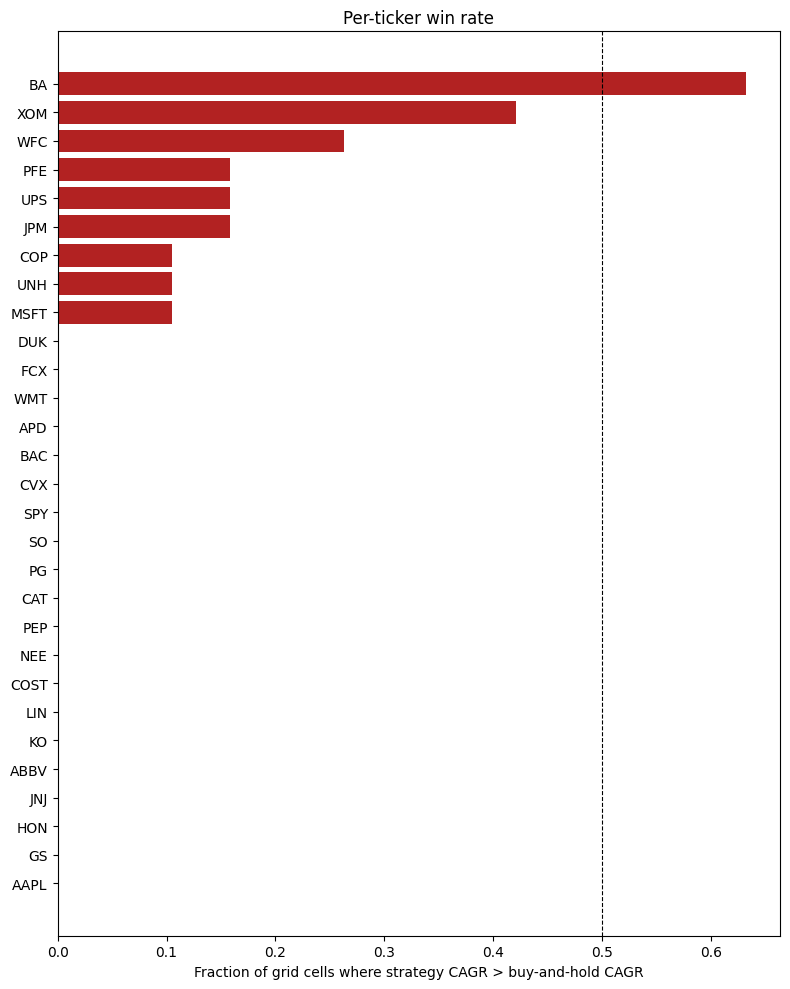

ticker
BA      0.631579
XOM     0.421053
WFC     0.263158
PFE     0.157895
UPS     0.157895
JPM     0.157895
COP     0.105263
UNH     0.105263
MSFT    0.105263
DUK     0.000000
FCX     0.000000
WMT     0.000000
APD     0.000000
BAC     0.000000
CVX     0.000000
SPY     0.000000
SO      0.000000
PG      0.000000
CAT     0.000000
PEP     0.000000
NEE     0.000000
COST    0.000000
LIN     0.000000
KO      0.000000
ABBV    0.000000
JNJ     0.000000
HON     0.000000
GS      0.000000
AAPL    0.000000
Name: edge, dtype: float64

In [5]:
win_rate = (
    df.groupby("ticker")["edge"]
    .apply(lambda s: (s > 0).mean())
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 10))
colors = ["firebrick" if w > 0 else "steelblue" for w in win_rate.values]
ax.barh(win_rate.index[::-1], win_rate.values[::-1], color=colors[::-1])
ax.set_xlabel("Fraction of grid cells where strategy CAGR > buy-and-hold CAGR")
ax.set_title("Per-ticker win rate")
ax.axvline(0.5, color="black", linewidth=0.8, linestyle="--")
plt.tight_layout()
plt.show()

win_rate

Boeing (BA) is the one real exception — the strategy beats buy-and-hold in 63% of its grid cells, clearly different from everything else here. That tracks with BA's own story over this window: a stock that spent long stretches in a drawdown (737 MAX groundings, COVID's hit to travel, production problems) rather than compounding steadily upward, which is exactly the kind of choppy, non-trending price path where staying out of the market some of the time can help instead of hurt. Exxon (XOM) is a distant second at 42%, still net negative on average edge. Every other ticker, AAPL included, has a win rate under 16%, and 19 of the 29 tickers have a win rate of exactly 0% — the strategy didn't beat buy-and-hold in a single one of their 19 parameter combinations.

## Mean and median edge, with a bootstrap confidence interval

The 551 rows in this dataset are not 551 independent observations. Every ticker contributes 19 overlapping parameter combinations run against the same price series, and neighboring short/long windows produce highly correlated signals and returns. Treating each row as an independent draw would understate the uncertainty in these estimates.

To keep the correlation structure honest, the bootstrap below resamples at the **ticker** level, not the cell level: for each of 10,000 iterations, it draws 29 tickers with replacement, averages each ticker's own mean edge across its 19 cells, and takes the mean (and separately, the median) of those. This treats each ticker as one unit of evidence rather than treating its 19 correlated cells as 19 separate ones.

This interval is still indicative, not a formal significance test — 29 tickers over one shared historical window is a small and non-random sample (see the survivorship-bias note above), and this doesn't correct for the fact that the short/long grid itself was chosen after seeing v1's result.

In [6]:
per_ticker_mean_edge = df.groupby("ticker")["edge"].mean()

rng = np.random.default_rng(42)
n_boot = 10_000
boot_means = np.empty(n_boot)
boot_medians = np.empty(n_boot)

tickers = per_ticker_mean_edge.index.to_numpy()
values = per_ticker_mean_edge.to_numpy()

for i in range(n_boot):
    sample = rng.choice(values, size=len(values), replace=True)
    boot_means[i] = sample.mean()
    boot_medians[i] = np.median(sample)

mean_edge = per_ticker_mean_edge.mean()
median_edge = per_ticker_mean_edge.median()
mean_ci = np.percentile(boot_means, [2.5, 97.5])
median_ci = np.percentile(boot_medians, [2.5, 97.5])

print(f"Per-ticker mean edge: {mean_edge:.2%}  (95% bootstrap CI: [{mean_ci[0]:.2%}, {mean_ci[1]:.2%}])")
print(f"Per-ticker median edge: {median_edge:.2%}  (95% bootstrap CI: [{median_ci[0]:.2%}, {median_ci[1]:.2%}])")

Per-ticker mean edge: -7.76%  (95% bootstrap CI: [-9.44%, -6.16%])
Per-ticker median edge: -7.19%  (95% bootstrap CI: [-8.76%, -6.08%])


Both intervals sit entirely below zero and nowhere near it. Given 29 tickers isn't a large sample, and given the caveats above about survivorship bias and the shared time window, I wouldn't treat this as proof the strategy is bad in some universal sense. But within this universe, over this window, the underperformance isn't a marginal or borderline result — it's consistent and fairly large across almost every ticker tested.

## What this shows

The AAPL 20/50 result from v1 wasn't a fluke of picking AAPL. Across 29 tickers spanning eight sectors and 19 parameter combinations each, the strategy beat buy-and-hold in only about 7% of cells on CAGR and 9% on Sharpe. AAPL's own 20/50 result sits slightly worse than the average outcome for AAPL across its full parameter grid, and worse than the overall median across the whole sweep — so if anything, v1 undersold how consistently this loses, not oversold it.

The one real exception is Boeing, where the strategy actually wins more often than not, plausibly because BA spent much of this window in extended drawdowns rather than a smooth uptrend — the kind of price path trend-following is supposed to help with. Energy (XOM) is a weaker, second-place exception. Every other name loses in the large majority of its parameter combinations, and most lose in literally all of them.

I'd read this as: over 2019-2026, in a survivorship-biased sample of large, liquid US stocks that mostly trended upward, a 20/50-style SMA crossover reliably gives up return relative to just holding, and that's not specific to the parameter pair or to AAPL. What it doesn't tell me is whether this generalizes to a different market regime, a genuinely random (survivorship-bias-free) universe, or assets with less directional persistence than large-cap US equities in a bull run — which is exactly what walk-forward validation and a broader/different universe would help check next.